In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()

x_train = (x_train.astype("float32") - 127.5) / 127.5

print(x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3)


In [3]:
latent_dim = 100

In [4]:
from tensorflow.keras import layers

def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(256, activation="relu", input_dim=latent_dim))
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.Dense(1024, activation="relu"))

    model.add(layers.Dense(32*32*3, activation="tanh"))
    model.add(layers.Reshape((32,32,3)))

    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3072)           │     3,148,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,831,552 (14.62 MB)

 Trainable params: 3,831,552 (14.62 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
noise = np.random.normal(0,1,(10,latent_dim))

generated_images = generator.predict(noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


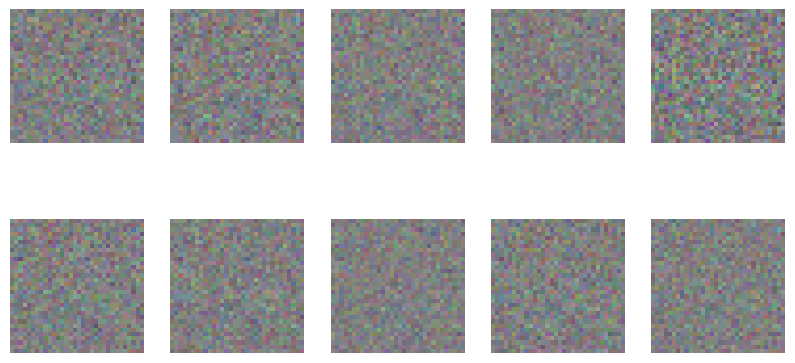

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    img = (generated_images[i] + 1)/2
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [7]:
z1 = np.random.normal(0,1,(1,latent_dim))
z2 = np.random.normal(0,1,(1,latent_dim))

alphas = np.linspace(0,1,10)

interpolated = []

for alpha in alphas:

    z = (1-alpha)*z1 + alpha*z2
    img = generator.predict(z)
    interpolated.append(img[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


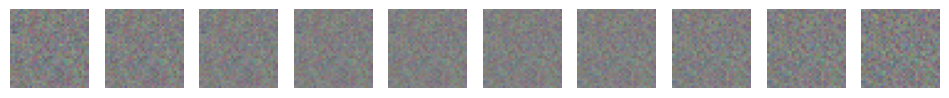

In [8]:
plt.figure(figsize=(12,2))

for i,img in enumerate(interpolated):

    plt.subplot(1,10,i+1)
    img = (img+1)/2
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [9]:
img = (generated_images[0]+1)/2

plt.imsave("gan_artistic_output.png", img)

In [10]:
from google.colab import files
files.download("gan_artistic_output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>